## 1. 📦 Install & Import Libraries

In [10]:
import os
import numpy as np
from glob import glob
from PIL import Image
from collections import Counter
import itertools

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, \
                            precision_score, recall_score, f1_score

import albumentations as A
from albumentations.pytorch import ToTensorV2

import matplotlib.pyplot as plt
from tqdm import tqdm

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device        : {DEVICE}")
print(f"GPUs available: {torch.cuda.device_count()}")

Device        : cuda
GPUs available: 2


## 2. ⚙️ Configuration & Hyperparameters


In [11]:
class CFG:
    DATA_DIR      = "/kaggle/input/datasets/briscdataset/brisc2025/brisc2025"
    CLS_TRAIN_DIR = os.path.join(DATA_DIR, "classification_task/train")
    CLS_TEST_DIR  = os.path.join(DATA_DIR, "classification_task/test")

    IMG_SIZE      = 256
    IN_CHANNELS   = 3
    NUM_CLASSES   = 4

    EPOCHS        = 30
    BATCH_SIZE    = 32
    LR            = 2e-4   # Back to normal LR — training from scratch
    VAL_SPLIT     = 0.15
    NUM_WORKERS   = 4

    WARMUP_EPOCHS = 0      # No warmup needed — no pretrained weights to protect

    SAVE_PATH     = "/kaggle/working/unet_classifier_best.pth"
    BACKUP_PATH   = "/kaggle/working/unet_classifier_epoch{}.pth"

LABEL_MAP   = {"glioma": 0, "meningioma": 1, "pituitary": 2, "no_tumor": 3}
CLASS_NAMES = ["Glioma", "Meningioma", "Pituitary", "No Tumor"]

## 3. 🗂️ Dataset Class

In [12]:
class BRISCClassificationDataset(Dataset):
    """
    Loads images from classification_task folder structure.
    Label is derived from folder name — no filename parsing needed.

        classification_task/train/
            glioma/       → label 0
            meningioma/   → label 1
            pituitary/    → label 2
            no_tumor/     → label 3
    """
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = np.array(Image.open(self.image_paths[idx]).convert("RGB"))
        label = self.labels[idx]

        if self.transform:
            out   = self.transform(image=image)
            image = out["image"]

        return image, torch.tensor(label, dtype=torch.long)


def load_cls_data(root_dir):
    """Walk through each class folder and collect paths + labels."""
    image_paths, labels = [], []

    for class_name, label_idx in LABEL_MAP.items():
        folder = os.path.join(root_dir, class_name)
        if not os.path.exists(folder):
            print(f"  WARNING: {folder} not found")
            continue
        files = sorted(glob(os.path.join(folder, "*")))
        image_paths.extend(files)
        labels.extend([label_idx] * len(files))
        print(f"  {class_name:<12}: {len(files)} images")

    print(f"  {'Total':<12}: {len(image_paths)} images")
    print(f"  Distribution : {Counter(labels)}")
    return image_paths, labels

## 4. 🔄 Augmentation & DataLoaders

In [13]:
train_transform = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.ElasticTransform(alpha=1, sigma=50, p=0.3),
    A.GaussNoise(p=0.2),
    A.CoarseDropout(max_holes=8, max_height=32,
                    max_width=32, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Load paths and labels
print("Training data:")
train_img_paths, train_labels = load_cls_data(CFG.CLS_TRAIN_DIR)

print("\nTest data:")
test_img_paths, test_labels = load_cls_data(CFG.CLS_TEST_DIR)

# Stratified split — preserves class ratio in each subset
tr_imgs, vl_imgs, tr_lbls, vl_lbls = train_test_split(
    train_img_paths, train_labels,
    test_size    = CFG.VAL_SPLIT,
    random_state = SEED,
    stratify     = train_labels
)

print(f"\nTrain : {len(tr_imgs)}")
print(f"Val   : {len(vl_imgs)}")
print(f"Test  : {len(test_img_paths)}")

# Class weights — inverse frequency to handle class imbalance
# Rarer classes (no_tumor) get higher weight so the loss
# penalizes missing them more heavily
cls_counts  = torch.tensor(
    [tr_lbls.count(i) for i in range(CFG.NUM_CLASSES)],
    dtype=torch.float
)
cls_weights = (1.0 / cls_counts)
cls_weights = cls_weights / cls_weights.sum() * CFG.NUM_CLASSES
cls_weights = cls_weights.to(DEVICE)
print(f"\nClass counts : {cls_counts.tolist()}")
print(f"Class weights: {cls_weights.tolist()}")

# Datasets
train_ds = BRISCClassificationDataset(tr_imgs, tr_lbls,
                                       transform=train_transform)
val_ds   = BRISCClassificationDataset(vl_imgs, vl_lbls,
                                       transform=val_transform)
test_ds  = BRISCClassificationDataset(test_img_paths, test_labels,
                                       transform=val_transform)

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE,
                          shuffle=True,  num_workers=CFG.NUM_WORKERS,
                          pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG.BATCH_SIZE,
                          shuffle=False, num_workers=CFG.NUM_WORKERS,
                          pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG.BATCH_SIZE,
                          shuffle=False, num_workers=CFG.NUM_WORKERS,
                          pin_memory=True)

# Sanity check
imgs, lbls = next(iter(train_loader))
print(f"\nBatch image shape : {imgs.shape}")
print(f"Batch label dist  : {Counter(lbls.tolist())}")

Training data:
  glioma      : 1147 images
  meningioma  : 1329 images
  pituitary   : 1457 images
  no_tumor    : 1067 images
  Total       : 5000 images
  Distribution : Counter({2: 1457, 1: 1329, 0: 1147, 3: 1067})

Test data:
  glioma      : 254 images
  meningioma  : 306 images
  pituitary   : 300 images
  no_tumor    : 140 images
  Total       : 1000 images
  Distribution : Counter({1: 306, 2: 300, 0: 254, 3: 140})

Train : 4250
Val   : 750
Test  : 1000

Class counts : [975.0, 1130.0, 1238.0, 907.0]
Class weights: [1.0737202167510986, 0.9264400601387024, 0.845619797706604, 1.1542197465896606]


/tmp/ipykernel_55/1576163668.py:9: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=32,



Batch image shape : torch.Size([32, 3, 256, 256])
Batch label dist  : Counter({2: 9, 0: 9, 1: 8, 3: 6})


## 5. 🏗️ U-Net From Scratch

In [16]:
class DoubleConv(nn.Module):
    """Conv → BN → ReLU → Conv → BN → ReLU"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, kernel_size=3,
                      padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3,
                      padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

In [17]:
class EncoderBlock(nn.Module):
    """DoubleConv + MaxPool. Returns (skip, downsampled)."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = DoubleConv(in_ch, out_ch)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        skip = self.conv(x)
        down = self.pool(skip)
        return skip, down

In [18]:
class UNetClassifier(nn.Module):
    """
    U-Net encoder + bottleneck used as a feature extractor
    for 4-class brain tumor classification.

    The decoder is completely omitted — it only exists for
    pixel-wise segmentation which we don't need here.

    Flow:
        Input  (B, 3,    256, 256)
        Enc1   (B, 64,   128, 128)
        Enc2   (B, 128,  64,  64)
        Enc3   (B, 256,  32,  32)
        Enc4   (B, 512,  16,  16)
        Bottle (B, 1024, 8,   8)
        GAP    (B, 1024)
        FC     (B, 4)

    Skip connections are discarded — they carry spatial detail
    which is irrelevant for image-level classification.
    """
    def __init__(self, in_channels=3, num_classes=4,
                 features=[64, 128, 256, 512]):
        super().__init__()

        # Encoder
        self.encoders = nn.ModuleList()
        prev_ch = in_channels
        for f in features:
            self.encoders.append(EncoderBlock(prev_ch, f))
            prev_ch = f

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # Classification head
        # AdaptiveAvgPool collapses (B, 1024, 8, 8) → (B, 1024)
        # regardless of spatial size — makes model resolution-agnostic
        self.cls_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(features[-1] * 2, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        """
        Kaiming init for conv layers, Xavier for linear.
        Prevents vanishing/exploding gradients at the
        start of training from scratch.
        """
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight,
                                        mode="fan_out",
                                        nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias,   0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # Encoder — skip connections discarded
        for encoder in self.encoders:
            _, x = encoder(x)

        # Bottleneck
        x = self.bottleneck(x)

        # Classify
        return self.cls_head(x)


# Instantiate
model = UNetClassifier(
    in_channels = CFG.IN_CHANNELS,
    num_classes = CFG.NUM_CLASSES
)

# Wrap for dual GPU
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

model = model.to(DEVICE)

total = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total:,}")

# Forward pass check
dummy = torch.randn(2, 3, CFG.IMG_SIZE, CFG.IMG_SIZE).to(DEVICE)
out   = model(dummy)
print(f"Input  : {dummy.shape}")
print(f"Output : {out.shape}")    # (2, 4)

Using 2 GPUs!
Total parameters: 19,504,324
Input  : torch.Size([2, 3, 256, 256])
Output : torch.Size([2, 4])


## 6. 📐 Loss Functions & Metrics

In [19]:
# Weighted CrossEntropyLoss
# Penalizes misclassifying minority classes more heavily
criterion = nn.CrossEntropyLoss(weight=cls_weights)


def accuracy(logits, labels):
    """Fraction of correctly predicted samples in a batch."""
    return (logits.argmax(dim=1) == labels).float().mean().item()


def save_checkpoint(model, optimizer, scheduler,
                    epoch, best_acc, history, path):
    """Safely unwraps DataParallel before saving."""
    state = model.module.state_dict() \
            if isinstance(model, nn.DataParallel) \
            else model.state_dict()
    torch.save({
        "epoch"    : epoch,
        "model"    : state,
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "best_acc" : best_acc,
        "history"  : history
    }, path)
    

def load_checkpoint(path, device):
    """
    Loads checkpoint into a fresh UNetClassifier.
    Strips module. prefix from DataParallel automatically.
    """
    ckpt  = torch.load(path, map_location=device)
    state = {k.replace("module.", ""): v
             for k, v in ckpt["model"].items()}
    m = UNetClassifier(
        in_channels = CFG.IN_CHANNELS,
        num_classes = CFG.NUM_CLASSES
    )
    m.load_state_dict(state)
    if torch.cuda.device_count() > 1:
        m = nn.DataParallel(m)
    return m.to(device), ckpt


print("Loss, metrics and checkpoint helpers ready!")

Loss, metrics and checkpoint helpers ready!


## 7. 🚀 Training Loop

In [25]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_acc = 0, 0

    for images, labels in tqdm(loader, desc="Train", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()

        # Gradient clipping — prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        total_acc  += accuracy(logits.detach(), labels)

    n = len(loader)
    return total_loss / n, total_acc / n


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss, total_acc = 0, 0

    for images, labels in tqdm(loader, desc="Val", leave=False):
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images)
        total_loss += criterion(logits, labels).item()
        total_acc  += accuracy(logits, labels)

    n = len(loader)
    return total_loss / n, total_acc / n


print("Train and validate functions ready!")

Train and validate functions ready!


In [26]:
optimizer = Adam(model.parameters(),
                 lr=CFG.LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer,
                               T_max=CFG.EPOCHS, eta_min=1e-6)

history  = {"train_loss":[], "val_loss":[],
            "train_acc" :[], "val_acc" :[]}
best_acc = 0.0

print(f"{'Epoch':>5} | {'TrLoss':>7} | {'TrAcc':>7} | "
      f"{'VlLoss':>7} | {'VlAcc':>7}")
print("-" * 50)

for epoch in range(1, CFG.EPOCHS + 1):

    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE
    )
    vl_loss, vl_acc = validate(
        model, val_loader, criterion, DEVICE
    )
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    # Save best model based on validation accuracy
    if vl_acc > best_acc:
        best_acc = vl_acc
        save_checkpoint(model, optimizer, scheduler,
                        epoch, best_acc, history,
                        CFG.SAVE_PATH)
        tag = " ✅"
    else:
        tag = ""

    # Backup every 5 epochs
    if epoch % 5 == 0:
        save_checkpoint(model, optimizer, scheduler,
                        epoch, best_acc, history,
                        CFG.BACKUP_PATH.format(epoch))
        print(f"  💾 Backup saved at epoch {epoch}")

    print(f"{epoch:>5} | {tr_loss:>7.4f} | {tr_acc:>6.2%} | "
          f"{vl_loss:>7.4f} | {vl_acc:>6.2%}{tag}")

print(f"\nBest Validation Accuracy: {best_acc:.2%}")

Epoch |  TrLoss |   TrAcc |  VlLoss |   VlAcc
--------------------------------------------------


    1 |  1.1901 | 47.46% |  0.8422 | 65.29% ✅


    2 |  1.0022 | 56.90% |  0.7190 | 72.75% ✅


    3 |  0.9256 | 60.85% |  0.6320 | 76.25% ✅


    4 |  0.8743 | 64.37% |  0.6009 | 74.39%


...

   26 |  0.2330 | 91.55% |  0.1795 | 94.01%


   27 |  0.2287 | 91.15% |  0.1745 | 94.10%


   28 |  0.2421 | 91.06% |  0.1595 | 93.97%


   29 |  0.2155 | 92.11% |  0.1539 | 93.97%


  💾 Backup saved at epoch 30
   30 |  0.2071 | 92.35% |  0.1608 | 94.07%

Best Validation Accuracy: 94.10%


## 8. 📊 Plot Training Curves

In [27]:
# Load best checkpoint
model, ckpt = load_checkpoint(CFG.SAVE_PATH, DEVICE)
history     = ckpt["history"]
print(f"Loaded epoch {ckpt['epoch']} | "
      f"Best Val Acc: {ckpt['best_acc']:.2%}")


# Collect all test predictions in one pass
@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()
    all_logits, all_labels = [], []

    for images, labels in tqdm(loader, desc="Testing"):
        images = images.to(device)
        logits = model(images)
        all_logits.append(logits.cpu())
        all_labels.append(labels.cpu())

    all_logits    = torch.cat(all_logits, dim=0)
    all_labels    = torch.cat(all_labels, dim=0)
    all_preds     = all_logits.argmax(dim=1).numpy()
    all_labels_np = all_labels.numpy()
    all_probs     = torch.softmax(all_logits, dim=1).numpy()

    acc = (all_preds == all_labels_np).mean()
    print(f"\nTest Accuracy : {acc:.2%}")
    print(f"Label dist    : {Counter(all_labels_np)}")
    print(f"Pred  dist    : {Counter(all_preds)}")

    return all_preds, all_labels_np, all_probs


all_preds, all_labels_np, all_probs = collect_predictions(
    model, test_loader, DEVICE
)

Loaded epoch 24 | Best Val Acc: 94.10%


Testing: 100%|██████████| 32/32 [00:04<00:00,  6.58it/s]



Test Accuracy : 92.40%
Label dist    : Counter({np.int64(1): 306, np.int64(2): 300, np.int64(0): 254, np.int64(3): 140})
Pred  dist    : Counter({np.int64(2): 325, np.int64(1): 281, np.int64(0): 233, np.int64(3): 161})


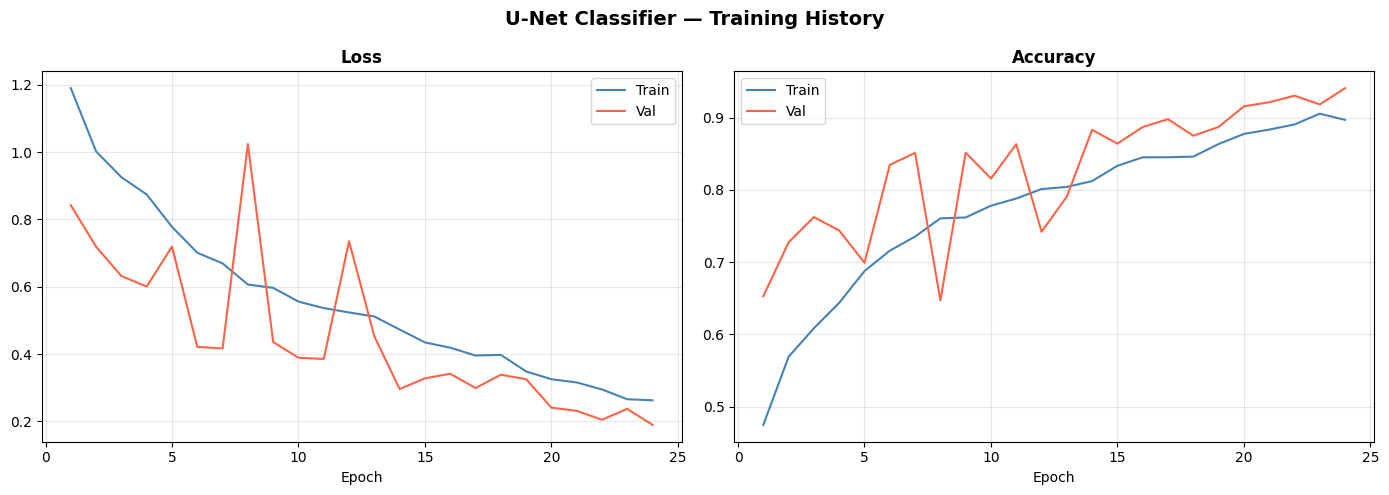

In [28]:
# Plot 1 — Training curves
def plot_training_curves(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("U-Net Classifier — Training History",
                 fontsize=14, fontweight="bold")

    for ax, (tr_k, vl_k, title) in zip(axes, [
        ("train_loss", "val_loss", "Loss"),
        ("train_acc",  "val_acc",  "Accuracy")
    ]):
        ax.plot(epochs, history[tr_k],
                label="Train", color="steelblue")
        ax.plot(epochs, history[vl_k],
                label="Val",   color="tomato")
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("/kaggle/working/cls_training_curves.png",
                dpi=150, bbox_inches="tight")
    plt.show()

plot_training_curves(history)

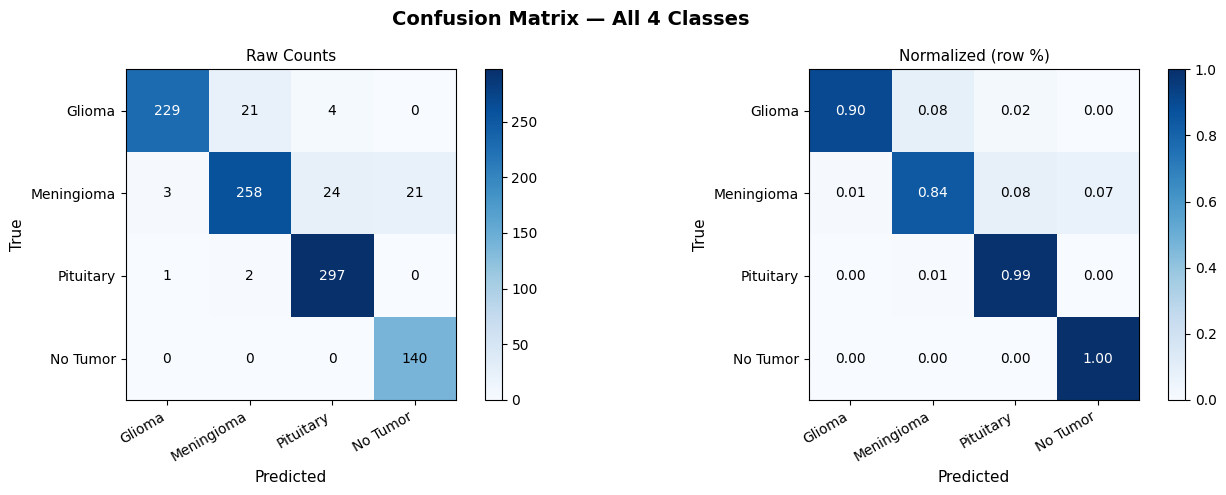

In [29]:
# Plot 2 — Confusion matrix
def plot_confusion_matrix(all_preds, all_labels, class_names):
    cm      = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Confusion Matrix — All 4 Classes",
                 fontsize=14, fontweight="bold")

    for ax, data, title, fmt in zip(
        axes,
        [cm, cm_norm],
        ["Raw Counts", "Normalized (row %)"],
        ["d", ".2f"]
    ):
        im = ax.imshow(data, cmap=plt.cm.Blues,
                       interpolation="nearest")
        plt.colorbar(im, ax=ax)
        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels(class_names, rotation=30, ha="right")
        ax.set_yticklabels(class_names)
        ax.set_xlabel("Predicted", fontsize=11)
        ax.set_ylabel("True",      fontsize=11)
        ax.set_title(title,        fontsize=11)
        thresh = data.max() / 2.0
        for i, j in itertools.product(range(data.shape[0]),
                                       range(data.shape[1])):
            ax.text(j, i, format(data[i, j], fmt),
                    ha="center", va="center", fontsize=10,
                    color="white" if data[i, j] > thresh
                    else "black")

    plt.tight_layout()
    plt.savefig("/kaggle/working/cls_confusion_matrix.png",
                dpi=150, bbox_inches="tight")
    plt.show()

plot_confusion_matrix(all_preds, all_labels_np, CLASS_NAMES)

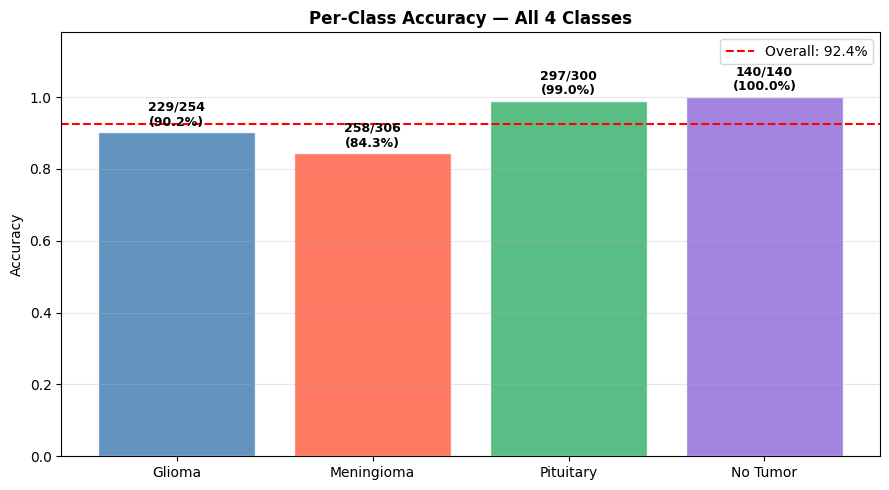

In [30]:
# Plot 3 — Per-class accuracy
def plot_per_class_accuracy(all_preds, all_labels, class_names):
    accs, corrects, totals = [], [], []
    for i in range(len(class_names)):
        mask    = all_labels == i
        total   = mask.sum()
        correct = (all_preds[mask] == i).sum() if total > 0 else 0
        accs.append(correct / total if total > 0 else 0)
        corrects.append(correct)
        totals.append(total)

    colors = ["steelblue", "tomato", "mediumseagreen", "mediumpurple"]
    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(class_names, accs, color=colors,
                  edgecolor="white", alpha=0.85)

    for bar, c, t, a in zip(bars, corrects, totals, accs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{c}/{t}\n({a:.1%})",
                ha="center", va="bottom",
                fontsize=9, fontweight="bold")

    overall = (all_preds == all_labels).mean()
    ax.axhline(overall, color="red", linestyle="--",
               linewidth=1.5, label=f"Overall: {overall:.1%}")
    ax.set_ylim(0, 1.18)
    ax.set_ylabel("Accuracy")
    ax.set_title("Per-Class Accuracy — All 4 Classes",
                 fontweight="bold")
    ax.legend(); ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig("/kaggle/working/cls_per_class_accuracy.png",
                dpi=150, bbox_inches="tight")
    plt.show()

plot_per_class_accuracy(all_preds, all_labels_np, CLASS_NAMES)

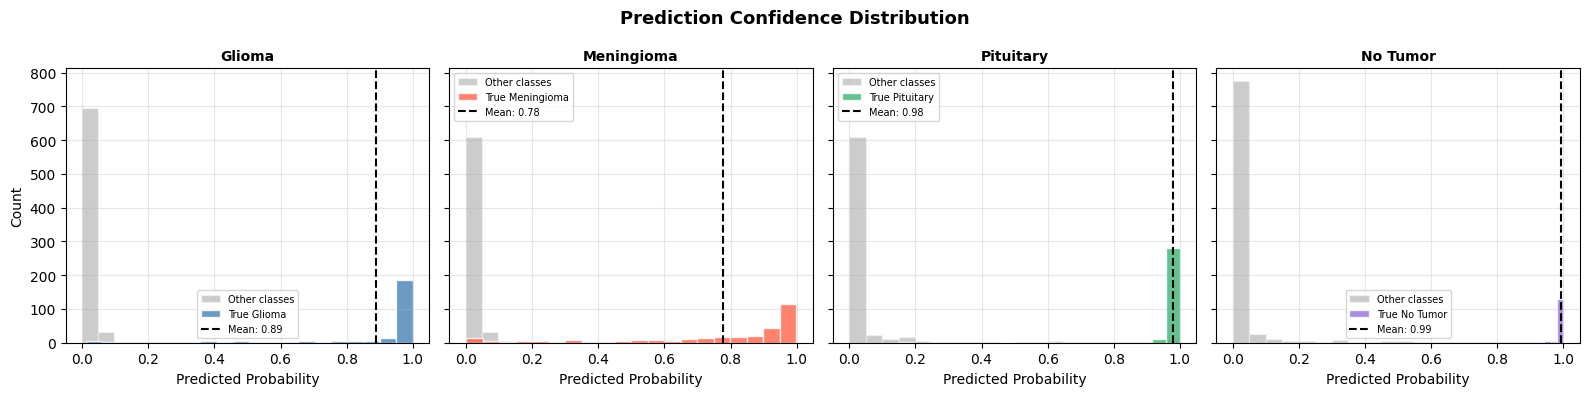

In [32]:
# Plot 4 — Confidence distribution
def plot_confidence_distribution(all_probs, all_labels, class_names):
    colors = ["steelblue", "tomato", "mediumseagreen", "mediumpurple"]
    fig, axes = plt.subplots(1, len(class_names),
                             figsize=(16, 4), sharey=True)
    fig.suptitle("Prediction Confidence Distribution",
                 fontsize=13, fontweight="bold")

    for i, (ax, name, color) in enumerate(
        zip(axes, class_names, colors)
    ):
        true_mask   = all_labels == i
        true_probs  = all_probs[true_mask,  i]
        other_probs = all_probs[~true_mask, i]

        ax.hist(other_probs, bins=20, alpha=0.4, color="gray",
                label="Other classes", edgecolor="white")
        ax.hist(true_probs,  bins=20, alpha=0.8, color=color,
                label=f"True {name}", edgecolor="white")
        ax.axvline(true_probs.mean(), color="black",
                   linestyle="--", linewidth=1.5,
                   label=f"Mean: {true_probs.mean():.2f}")
        ax.set_title(name, fontsize=10, fontweight="bold")
        ax.set_xlabel("Predicted Probability")
        ax.legend(fontsize=7); ax.grid(alpha=0.3)

    axes[0].set_ylabel("Count")
    plt.tight_layout()
    plt.savefig("/kaggle/working/cls_confidence_dist.png",
                dpi=150, bbox_inches="tight")
    plt.show()

plot_confidence_distribution(all_probs, all_labels_np, CLASS_NAMES)

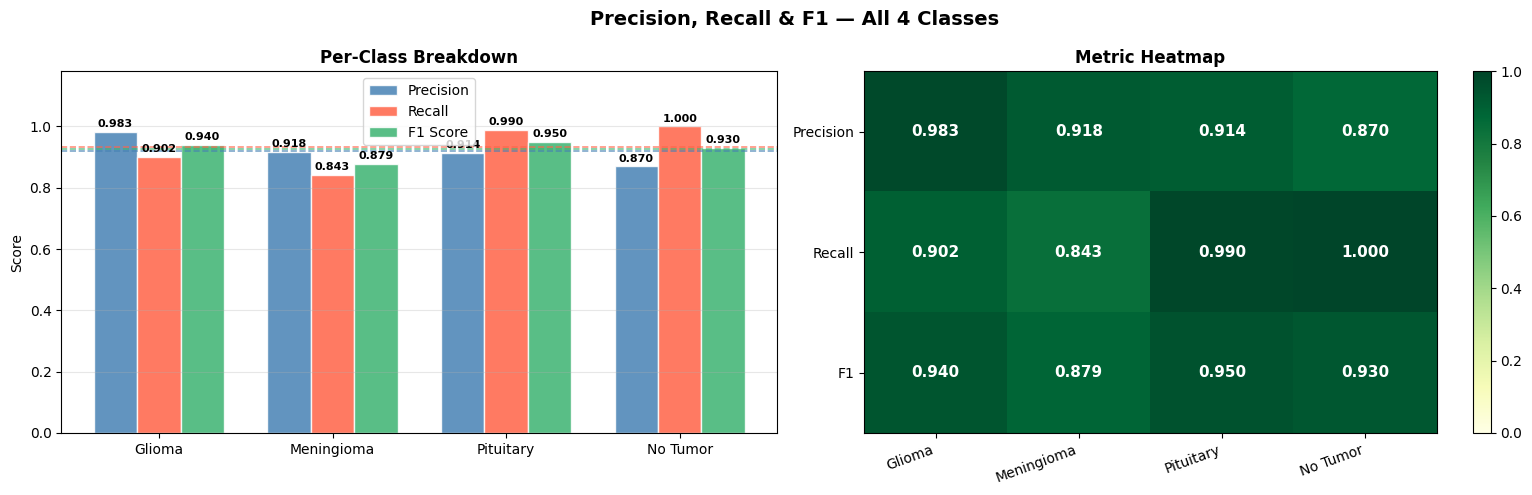


  Class           Precision   Recall       F1
  Glioma             0.9828   0.9016   0.9405
  Meningioma         0.9181   0.8431   0.8790
  Pituitary          0.9138   0.9900   0.9504
  No Tumor           0.8696   1.0000   0.9302
-------------------------------------------------------
  Macro Avg          0.9211   0.9337   0.9250


In [33]:
# Plot 5 — Precision, Recall, F1
def plot_precision_recall_f1(all_preds, all_labels, class_names):
    precision = precision_score(all_labels, all_preds,
                                average=None, zero_division=0)
    recall    = recall_score(   all_labels, all_preds,
                                average=None, zero_division=0)
    f1        = f1_score(       all_labels, all_preds,
                                average=None, zero_division=0)

    macro_p  = precision.mean()
    macro_r  = recall.mean()
    macro_f1 = f1.mean()

    x     = np.arange(len(class_names))
    width = 0.25

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle("Precision, Recall & F1 — All 4 Classes",
                 fontsize=14, fontweight="bold")

    ax = axes[0]
    b1 = ax.bar(x - width, precision, width,
                label="Precision",  color="steelblue",
                alpha=0.85, edgecolor="white")
    b2 = ax.bar(x,          recall,   width,
                label="Recall",     color="tomato",
                alpha=0.85, edgecolor="white")
    b3 = ax.bar(x + width,  f1,       width,
                label="F1 Score",   color="mediumseagreen",
                alpha=0.85, edgecolor="white")

    for bars in [b1, b2, b3]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.008,
                    f"{bar.get_height():.3f}",
                    ha="center", va="bottom",
                    fontsize=8, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(class_names, fontsize=10)
    ax.set_ylim(0, 1.18)
    ax.set_ylabel("Score")
    ax.set_title("Per-Class Breakdown", fontweight="bold")
    ax.axhline(macro_p,  color="steelblue",
               linestyle="--", linewidth=1.2, alpha=0.7)
    ax.axhline(macro_r,  color="tomato",
               linestyle="--", linewidth=1.2, alpha=0.7)
    ax.axhline(macro_f1, color="mediumseagreen",
               linestyle="--", linewidth=1.2, alpha=0.7)
    ax.legend(); ax.grid(axis="y", alpha=0.3)

    ax2  = axes[1]
    data = np.stack([precision, recall, f1], axis=0)
    im   = ax2.imshow(data, cmap="YlGn",
                      vmin=0, vmax=1, aspect="auto")
    plt.colorbar(im, ax=ax2)
    ax2.set_xticks(range(len(class_names)))
    ax2.set_yticks(range(3))
    ax2.set_xticklabels(class_names, fontsize=10,
                         rotation=20, ha="right")
    ax2.set_yticklabels(["Precision", "Recall", "F1"],
                         fontsize=10)
    ax2.set_title("Metric Heatmap", fontweight="bold")

    for i in range(3):
        for j in range(len(class_names)):
            ax2.text(j, i, f"{data[i, j]:.3f}",
                     ha="center", va="center",
                     fontsize=11, fontweight="bold",
                     color="black" if data[i, j] < 0.6
                     else "white")

    plt.tight_layout()
    plt.savefig("/kaggle/working/cls_precision_recall_f1.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    print("\n" + "=" * 55)
    print(f"  {'Class':<14} {'Precision':>10} "
          f"{'Recall':>8} {'F1':>8}")
    print("=" * 55)
    for i, name in enumerate(class_names):
        print(f"  {name:<14} {precision[i]:>10.4f} "
              f"{recall[i]:>8.4f} {f1[i]:>8.4f}")
    print("-" * 55)
    print(f"  {'Macro Avg':<14} {macro_p:>10.4f} "
          f"{macro_r:>8.4f} {macro_f1:>8.4f}")
    print("=" * 55)

plot_precision_recall_f1(all_preds, all_labels_np, CLASS_NAMES)


In [34]:
# Full classification report
print("\n" + "=" * 55)
print("     FULL 4-CLASS CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(
    all_labels_np, all_preds,
    target_names=CLASS_NAMES,
    digits=4
))


     FULL 4-CLASS CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Glioma     0.9828    0.9016    0.9405       254
  Meningioma     0.9181    0.8431    0.8790       306
   Pituitary     0.9138    0.9900    0.9504       300
    No Tumor     0.8696    1.0000    0.9302       140

    accuracy                         0.9240      1000
   macro avg     0.9211    0.9337    0.9250      1000
weighted avg     0.9265    0.9240    0.9232      1000

